# Lab 6

### My assigned state: Connecticut

In [3]:
# Secret manager function

import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

### Retrieving and applying secret info

In [4]:
# Connecting to database

import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

# Question 1
Write an SQL query to retrieve the yearly population for your state.

• Decide how to calculate year-over-year growth rate:

o Option A: compute growth rate in SQL (preferred for Don’t Move the
Data Principle)

o Option B: compute growth rate in Python after loading population data

o You may need AI assistance to write the join query correctly.

• Use Jupyter AI to help write the Python code that loads the results and creates a
line chart with the growth rate.

• Chart must include the state name in the title.

• Provide a markdown explanation.


In [5]:
# fips = '09'
# Population year over year
sql = """
SELECT
  year,
  pop,
  LAG(pop) OVER (ORDER BY year) AS prev_pop,
  ROUND(
    ( (pop - LAG(pop) OVER (ORDER BY year))
      / NULLIF(LAG(pop) OVER (ORDER BY year), 0)::numeric
    ) * 100,
    2
  ) AS yoy_growth_pct
FROM population
WHERE fips = '09'
ORDER BY year;
"""

In [6]:
import pandas as pd

df = pd.read_sql(sql, con=conn)
df.head() #show the top 5 rows

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/tmp/ipykernel_8963/3133119553.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, con=conn)


,year,pop,prev_pop,yoy_growth_pct
0,2005,3394751,NaN,NaN
1,2006,3504809,3394751.0,3.24
2,2007,3502309,3504809.0,-0.07
3,2008,3501252,3502309.0,-0.03
4,2009,3518288,3501252.0,0.49


# Using AI assistance to create charts

In [7]:
pip install -U pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install --only-binary=:all: "tiktoken>=0.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install "jupyter-ai-magics[all]" -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
safety-schemas 0.0.14 requires pydantic<2.10.0,>=2.6.0, but you have pydantic 2.12.0 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.2.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [10]:
import warnings
warnings.simplefilter('ignore')

In [11]:
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']

In [12]:
%load_ext jupyter_ai_magics

In [13]:
%%ai gpt4
Using the dataframe from up above a few rows, create python code for a line chart of yoy population growth over time. The df column is called yoy_growth_pct. Make sure to include the state name (Connecticut) in the title.

Here's the code in Python for creating a line chart for yoy population growth over time.

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df.index, df['yoy_growth_pct'])
plt.title('Year over Year Population Growth in Connecticut')
plt.xlabel('Year')
plt.ylabel('YOY Growth Percentage')
plt.show()
```

Please replace `df` with your actual DataFrame variable, and 'df.index' with the column representing the years if it's not the index of the DataFrame.

This will generate a line chart with the yoy growth percentage on the y-axis and the years on the x-axis, titled 'Year over Year Population Growth in Connecticut'.

Note however, that this cannot be done in just markdown. Markdown is essentially a text formatting syntax that does not support natively executable code. You can write the code in markdown, but it won't be executed. The python code can be executed in a Jupyter notebook or other python environments.

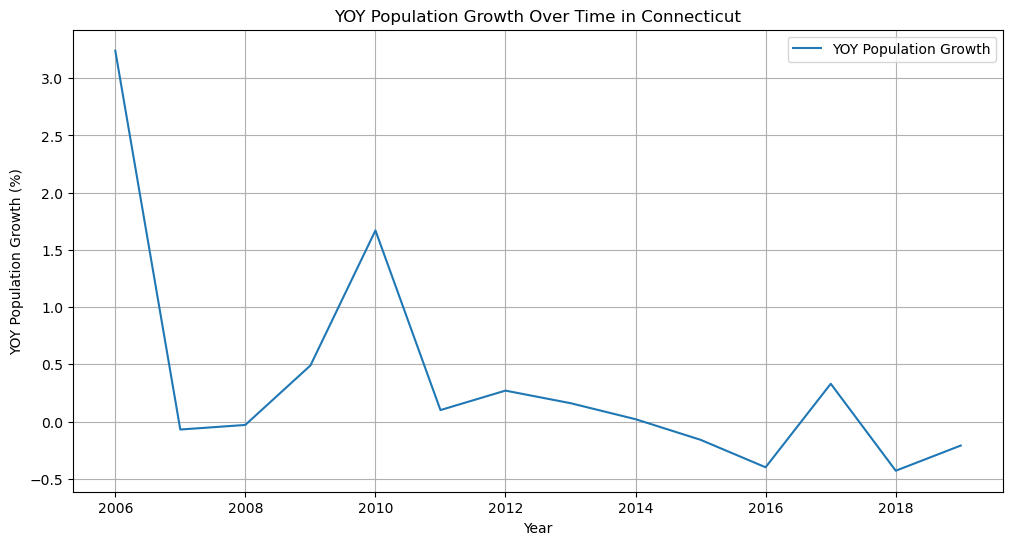

In [35]:
# Import the necessary library
import matplotlib.pyplot as plt

# Ensure 'year' is of datetime type
df['year'] = pd.to_datetime(df['year'], format='%Y')

# Sort DataFrame by 'year'
df = df.sort_values('year')

# Plot YOY population growth rate over time
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['yoy_growth_pct'], label='YOY Population Growth')

plt.xlabel('Year')
plt.ylabel('YOY Population Growth (%)')
plt.title('YOY Population Growth Over Time in Connecticut')
plt.legend()
plt.grid(True)
plt.show()

### Question 1 explanation: YoY Pop Growth in Connecticut was at its highest in 2006, and generally shrunk over the next 13 years (Except in 2009, 2010, and 2017).

# Question 2

Write an SQL query to join the income and population tables for your state,
selecting values for all years.

o You may need AI assistance to write the join query correctly.

• Load the result into pandas.

• Visualization: create a dual-axis chart in Python with Jupyter AI’s help:

o X-axis = year

o Left Y-axis = population (line)

o Right Y-axis = median household income (bar or line, different color)

• Chart must include the state name in the title.

In [36]:
# Join income and population tables, selecting values for all years
sql = """
SELECT 
  p.year,
  p.pop,
  i.income
FROM population AS p
JOIN income AS i
  ON p.fips = i.fips AND p.year = i.year
WHERE p.fips = '09'
ORDER BY p.year;
"""

In [37]:
df = pd.read_sql(sql, conn)

In [40]:
%%ai gpt4
Using the df above, create a dual-axis chart in python, with the x-axis as the year, the left y-axis as the population (line), and the right axis as median household income (bar or line, different color)

Here is a Python code snippet showing how to create a dual-axis chart. However, python code can't be executed in markdown. Therefore, you would need to run this in a Python environment such as Jupyter Notebook:

```python

# Import necessary libraries
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots()

# Plot population on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Population', color=color)
ax1.plot(df['year'], df['population'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a twin axis for the median household income
ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Median Household Income', color=color)
ax2.plot(df['year'], df['median_income'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Format the figure
fig.tight_layout()

# Display the plot
plt.show()
```
Please make sure to replace `'year'`,  `'population'` and `'median_income'` with the actual column names in your dataframe. Also replace `'df'` with your actual DataFrame object name.

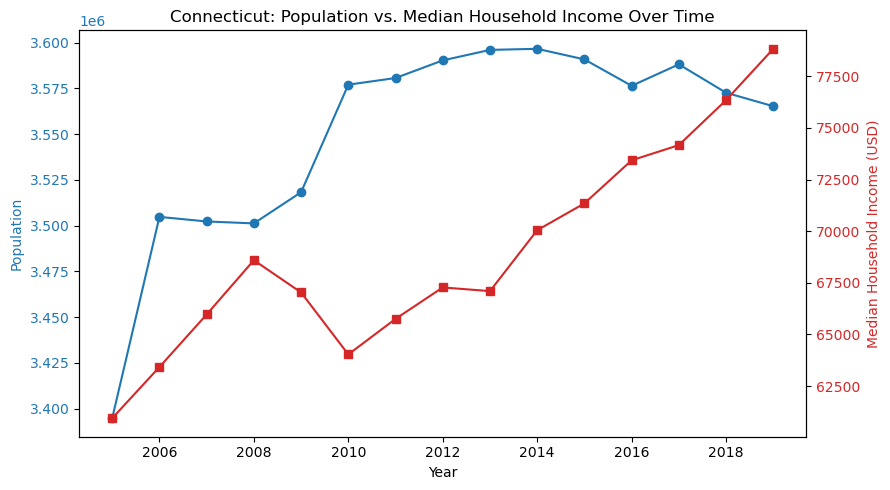

In [41]:
fig, ax1 = plt.subplots(figsize=(9,5))

# Left axis — Population
ax1.plot(df['year'], df['pop'], color='tab:blue', marker='o', label='Population')
ax1.set_xlabel('Year')
ax1.set_ylabel('Population', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis — Median Household Income
ax2 = ax1.twinx()
ax2.plot(df['year'], df['income'], color='tab:red', marker='s', label='Median Income')
ax2.set_ylabel('Median Household Income (USD)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Connecticut: Population vs. Median Household Income Over Time")
fig.tight_layout()
plt.show()

Provide a Markdown explanation: how do population and income trends
compare?

### Question 2 explanation: The two trends have a somewhat similar path until 2008. Starting after 2010, the Median Household Income steadily grows. On the other hand, Population appears to plateau after 2010.

# Question 3

Think of one additional question about population or income in your state. Examples:

o What is the annual growth rate of the population for the past years?

o Which year had the largest population increase?

• Write an SQL query to retrieve the needed data. You may need AI assistance to write the join query correctly

• Use Jupyter AI to generate Python code for visualization (line chart, bar chart, or
other appropriate type).

• Chart must include the state name in the title.

• Provide a Markdown explanation.

In [42]:
sql = """
SELECT
  p.year,
  p.pop,
  i.income,
  ROUND(
    (p.pop - LAG(p.pop) OVER (ORDER BY p.year)) / 
    NULLIF(LAG(p.pop) OVER (ORDER BY p.year), 0)::numeric * 100, 2
  ) AS pop_yoy_growth,
  ROUND(
    (i.income - LAG(i.income) OVER (ORDER BY i.year)) / 
    NULLIF(LAG(i.income) OVER (ORDER BY i.year), 0)::numeric * 100, 2
  ) AS income_yoy_growth
FROM population AS p
JOIN income AS i
  ON p.fips = i.fips AND p.year = i.year
WHERE p.fips = '09'
ORDER BY p.year;
"""

In [ ]:
df = pd.read_sql(sql, conn)

In [45]:
%%ai gpt4
I have a pandas DataFrame called df with columns year, pop, and income for Connecticut.
Please calculate the year-over-year percent growth for both pop and income (using .pct_change() * 100), add them as new columns pop_yoy_growth and income_yoy_growth, and then create a matplotlib line chart:

X-axis = year

Y-axis = percent growth

Blue line with circle markers for population growth

Red line with square markers for income growth
Include a legend, gridlines, labeled axes, and the title "Connecticut: Population vs. Income Year-over-Year Growth".
Ensure the chart looks clean and professional.

Below is the Python code for what you requested:

```python
# Import necessary library
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the year-over-year percent growth for 'pop' and 'income'
df['pop_yoy_growth'] = df['pop'].pct_change() * 100
df['income_yoy_growth'] = df['income'].pct_change() * 100

# Create a figure and a set of subplots
fig, ax = plt.subplots()

# Plot Population Year-over-Year Growth
ax.plot(df['year'], df['pop_yoy_growth'], color='blue', marker='o', label='Population Growth')

# Plot Income Year-over-Year Growth
ax.plot(df['year'], df['income_yoy_growth'], color='red', marker='s', label='Income Growth')

# Add labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Year-over-Year Growth (%)')
plt.title('Connecticut: Population vs. Income Year-over-Year Growth')

# Show grid and legend
ax.grid(True)
ax.legend(loc='best')

# Show the plot
plt.show()
```

As with previous responses, this Python code cannot be run in markdown. It must be executed in a Python environment such as Jupyter notebook. Please replace `'df'` with the actual name of your dataframe, and make sure the column names match those in your dataframe.

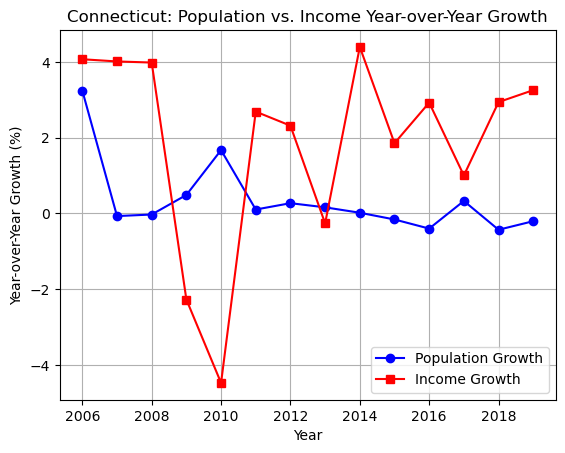

In [46]:

# Calculate the year-over-year percent growth for 'pop' and 'income'
df['pop_yoy_growth'] = df['pop'].pct_change() * 100
df['income_yoy_growth'] = df['income'].pct_change() * 100

# Create a figure and a set of subplots
fig, ax = plt.subplots()

# Plot Population Year-over-Year Growth
ax.plot(df['year'], df['pop_yoy_growth'], color='blue', marker='o', label='Population Growth')

# Plot Income Year-over-Year Growth
ax.plot(df['year'], df['income_yoy_growth'], color='red', marker='s', label='Income Growth')

# Add labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Year-over-Year Growth (%)')
plt.title('Connecticut: Population YoY vs. Income YoY Growth')

# Show grid and legend
ax.grid(True)
ax.legend(loc='best')

# Show the plot
plt.show()

### Question 3 explanation: The above graph shows YoY population growth compared to YoY income growth. We can see that compared to income growth, population growth stays relatively stagnant/ctable, where income growth is volatile. 

In [ ]:
conn.close()